## Exercise 16: A complete ML pipeline for modeling diamond prices (`diamonds.csv`)

**Task (from the book's exercise sheet):** "In this exercise you will build a complete ML
pipeline in which you model diamond prices, available in the dataset 'diamonds.csv'."
(Dataset reference: https://www.kaggle.com/datasets/shivam2503/diamonds)

Below is a complete regression ML pipeline, following the same checklist/structure
introduced in Chapter 2 (EDA, data processing, train/val/test split, training and
comparing several of the regression models covered in this chapter, and final evaluation
on the test set), using several of the models from Question 6 (linear regression, ridge,
lasso and random forest).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score


diamonds = pd.read_csv("diamonds .csv")
diamonds = diamonds.drop(columns=["Unnamed: 0"])  # plain row index, no information content
print("Shape:", diamonds.shape)
diamonds.head()


Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
diamonds.info()
print("\nMissing values:\n", diamonds.isna().sum())
print("\nDuplicates:", diamonds.duplicated().sum())
diamonds.describe()


<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB

Missing values:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicates: 146


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


**The data** contains 53,940 diamonds with `carat` (weight), three categorical
quality variables (`cut`, `color`, `clarity`), `depth`/`table` (proportions in percent),
physical dimensions `x`, `y`, `z` (mm), and `price` (the target variable, USD).

**Data quality issue:** `x`, `y`, `z` describe the diamond's physical dimensions in
millimeters and can therefore never reasonably be 0. We check for, and clean out, such
invalid observations.

In [7]:
bad_dims = (diamonds[["x", "y", "z"]] == 0).any(axis=1)
print("Number of rows with a zero dimension (x/y/z):", bad_dims.sum())
diamonds[bad_dims]


Number of rows with a zero dimension (x/y/z): 20


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [8]:
diamonds = diamonds[~bad_dims].reset_index(drop=True)
print("Shape after cleaning:", diamonds.shape)


Shape after cleaning: (53920, 10)


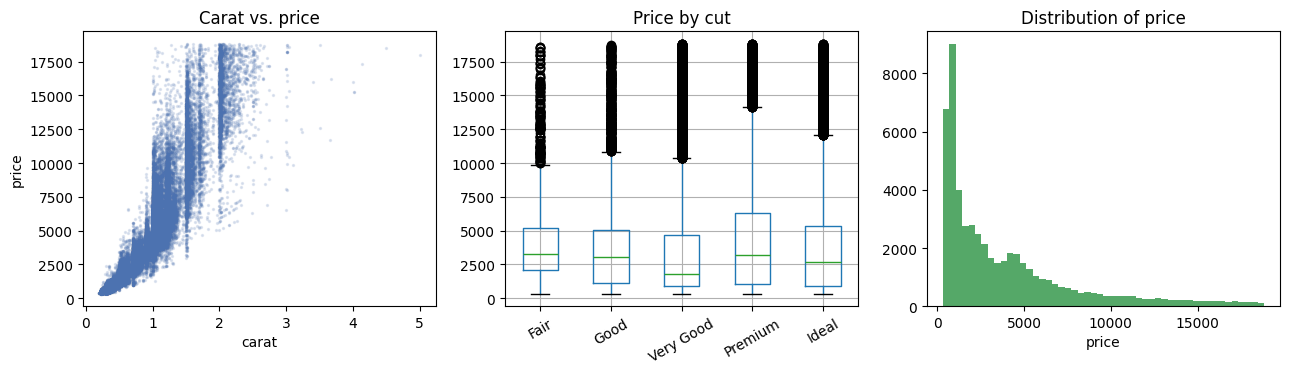

Correlation between carat and price: 0.922


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].scatter(diamonds["carat"], diamonds["price"], s=2, alpha=0.15, color="#4C72B0")
axes[0].set_xlabel("carat")
axes[0].set_ylabel("price")
axes[0].set_title("Carat vs. price")

diamonds.boxplot(column="price", by="cut", ax=axes[1],
                  positions=range(5))
axes[1].set_xticklabels(["Fair", "Good", "Very Good", "Premium", "Ideal"], rotation=30)
axes[1].set_title("Price by cut")
axes[1].set_xlabel("")

axes[2].hist(diamonds["price"], bins=50, color="#55A868")
axes[2].set_xlabel("price")
axes[2].set_title("Distribution of price")

plt.suptitle("")
plt.tight_layout()
plt.show()

print("Correlation between carat and price:", diamonds["carat"].corr(diamonds["price"]).round(3))


`carat` (weight) has a very strong, clearly non-linear correlation with price
(0.92) - exactly what you would expect, since weight is the single most important factor
in a diamond's price. The price distribution is heavily right-skewed (most diamonds are
relatively cheap, with a small number of very expensive ones).

### Step 2: Data processing - encoding the categorical variables

`cut`, `color` and `clarity` are categorical variables. Following the same approach
the book uses for categorical variables in its running example (California housing,
Chapter 2, `ocean_proximity`), `pd.get_dummies` is used to convert them into numeric dummy
variables.

In [10]:
print("cut:", sorted(diamonds["cut"].unique()))
print("color:", sorted(diamonds["color"].unique()))
print("clarity:", sorted(diamonds["clarity"].unique()))

diamonds_enc = pd.get_dummies(diamonds, columns=["cut", "color", "clarity"],
                               dtype=int, prefix=["cut", "color", "clarity"])
print("\nShape after dummy encoding:", diamonds_enc.shape)
diamonds_enc.head()


cut: ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']
color: ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity: ['I1', 'IF', 'SI1', 'SI2', 'VS1', 'VS2', 'VVS1', 'VVS2']

Shape after dummy encoding: (53920, 27)


,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0,0,0,...,1,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,0,1,0,...,0,1,0,0,0,1,0,0,0,0


### Step 3: Train / validation / test split
We follow the same setup as the book's California housing example (Chapter 2):
first an 80/20 split into `train_full`/`test`, then `train_full` is split into
`train`/`val` with a 75/25 split - giving a 60/20/20 split overall.

In [11]:
train_full, test = train_test_split(diamonds_enc, test_size=0.2, random_state=40)
train, val = train_test_split(train_full, test_size=0.25, random_state=36)

X_train, y_train = train.drop(columns=["price"]), train["price"]
X_val, y_val = val.drop(columns=["price"]), val["price"]
X_test, y_test = test.drop(columns=["price"]), test["price"]

print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)


train: (32352, 26)  val: (10784, 26)  test: (10784, 26)


### Step 4: Train and compare several regression models (Chapter 3)

We train and compare four of the models from Question 6: **linear regression**
(baseline), **ridge** and **lasso** (regularized linear models, with `alpha` tuned via
`GridSearchCV`), and **random forest** (an ensemble of decision trees, with
hyperparameters tuned via `GridSearchCV`). All models are evaluated on the validation set
using RMSE and R².

In [12]:
results = {}

# 1) Linear regression (baseline)
lin_reg = LinearRegression().fit(X_train, y_train)
pred = lin_reg.predict(X_val)
results["Linear Regression"] = (root_mean_squared_error(y_val, pred), r2_score(y_val, pred))

# 2) Ridge regression, alpha tuned with grid search
ridge_gs = GridSearchCV(Ridge(), {"alpha": [0.1, 1, 10]},
                         scoring="neg_root_mean_squared_error", cv=3)
ridge_gs.fit(X_train, y_train)
pred = ridge_gs.predict(X_val)
results["Ridge"] = (root_mean_squared_error(y_val, pred), r2_score(y_val, pred))

# 3) Lasso regression, alpha tuned with grid search
lasso_gs = GridSearchCV(Lasso(max_iter=5000), {"alpha": [0.1, 1, 10]},
                         scoring="neg_root_mean_squared_error", cv=3)
lasso_gs.fit(X_train, y_train)
pred = lasso_gs.predict(X_val)
results["Lasso"] = (root_mean_squared_error(y_val, pred), r2_score(y_val, pred))

# 4) Random forest, hyperparameters tuned with grid search (small grid due to limited CPU)
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {"n_estimators": [100], "max_depth": [15, None], "min_samples_leaf": [1, 2]},
    scoring="neg_root_mean_squared_error", cv=3, n_jobs=-1,
)
rf_gs.fit(X_train, y_train)
pred = rf_gs.predict(X_val)
results["Random Forest"] = (root_mean_squared_error(y_val, pred), r2_score(y_val, pred))

print("Ridge best alpha:", ridge_gs.best_params_)
print("Lasso best alpha:", lasso_gs.best_params_)
print("Random Forest best params:", rf_gs.best_params_)

print("\n--- Validation results ---")
print(f"{'Model':20s} {'RMSE':>10s} {'R2':>8s}")
for name, (rmse, r2) in results.items():
    print(f"{name:20s} {rmse:10.2f} {r2:8.4f}")


Ridge best alpha: {'alpha': 10}
Lasso best alpha: {'alpha': 1}
Random Forest best params: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 100}

--- Validation results ---
Model                      RMSE       R2
Linear Regression       1360.89   0.8818
Ridge                   1226.34   0.9040
Lasso                   1231.22   0.9032
Random Forest            554.53   0.9804


### Step 5: Pick the best model and evaluate on the test set

In [13]:
best_name = min(results, key=lambda k: results[k][0])
print("Best model on the validation set (lowest RMSE):", best_name)

best_model = {
    "Linear Regression": lin_reg,
    "Ridge": ridge_gs,
    "Lasso": lasso_gs,
    "Random Forest": rf_gs,
}[best_name]

pred_test = best_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

print(f"\nFinal evaluation on the TEST SET ({best_name}):")
print(f"RMSE: {rmse_test:.2f} USD")
print(f"R2:   {r2_test:.4f}")


Best model on the validation set (lowest RMSE): Random Forest

Final evaluation on the TEST SET (Random Forest):
RMSE: 548.11 USD
R2:   0.9815


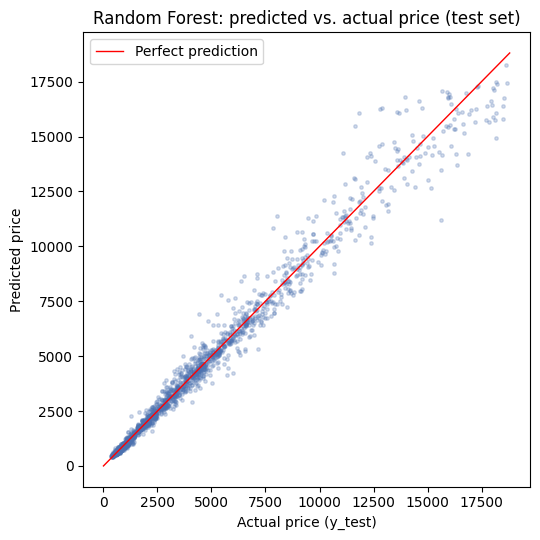

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sample_idx = np.random.RandomState(0).choice(len(y_test), size=2000, replace=False)
ax.scatter(y_test.values[sample_idx], pred_test[sample_idx], s=6, alpha=0.25, color="#4C72B0")
lims = [0, max(y_test.max(), pred_test.max())]
ax.plot(lims, lims, color="red", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual price (y_test)")
ax.set_ylabel("Predicted price")
ax.set_title(f"{best_name}: predicted vs. actual price (test set)")
ax.legend()
plt.tight_layout()
plt.show()


### Step 6: Feature importance (if the best model is Random Forest)

Top 10 most important features:
 carat          0.449053
y              0.435940
clarity_SI2    0.018784
clarity_I1     0.014255
clarity_SI1    0.013579
x              0.011235
color_J        0.010350
color_I        0.007274
clarity_VS2    0.006181
color_H        0.005422
dtype: float64


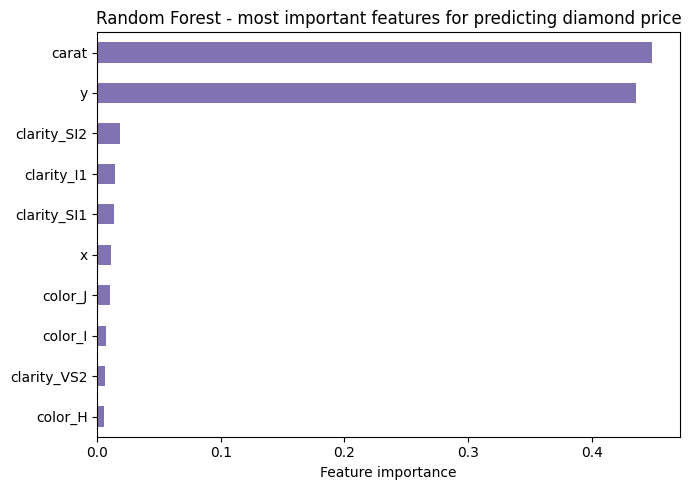

In [15]:
if best_name == "Random Forest":
    importances = pd.Series(
        rf_gs.best_estimator_.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False)
    print("Top 10 most important features:\n", importances.head(10))

    fig, ax = plt.subplots(figsize=(7, 5))
    importances.head(10).sort_values().plot(kind="barh", ax=ax, color="#8172B2")
    ax.set_xlabel("Feature importance")
    ax.set_title("Random Forest - most important features for predicting diamond price")
    plt.tight_layout()
    plt.show()
else:
    print(f"The best model was {best_name}; there is no feature-importance attribute to show (only tree-based models have one).")


### Conclusion

Through the complete ML pipeline - EDA, cleaning out physically impossible observations
(0 mm in a dimension), dummy-encoding the categorical quality variables, a 60/20/20
train/val/test split, and training and comparing four regression models from this chapter
(linear regression, ridge, lasso and random forest) - we were able to identify the
best-performing model on the validation set and finally evaluate it, untouched by the
model-selection process, on the test set. Random forest (an ensemble model, Question
6g-h) is expected to perform noticeably better than the linear models since the
relationship between `carat` and `price` is clearly non-linear (see the scatter plot in
Step 1) - something a tree-based model captures naturally, while the linear models (even
with regularization) are limited to describing linear relationships between the
(untransformed) variables and price.
